### LIBS

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Gráficos

### Ocupação e Receita VS Custos

Processamento concluído.


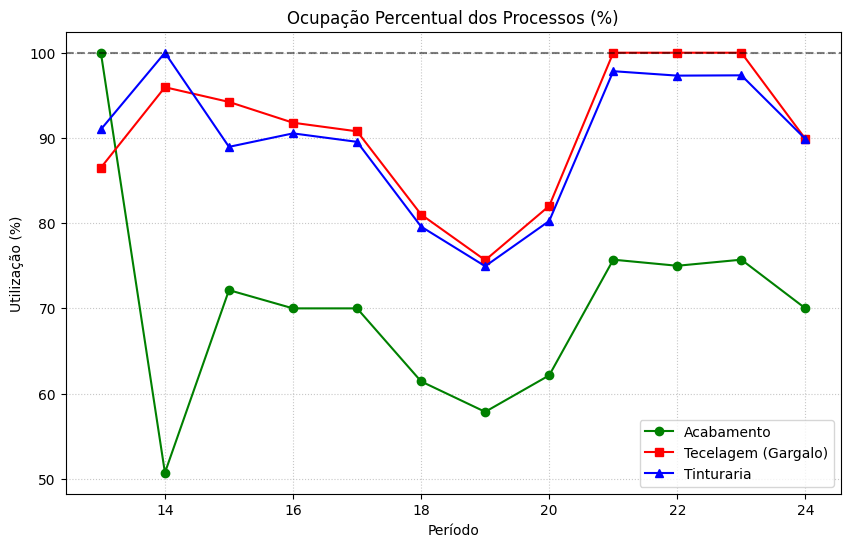

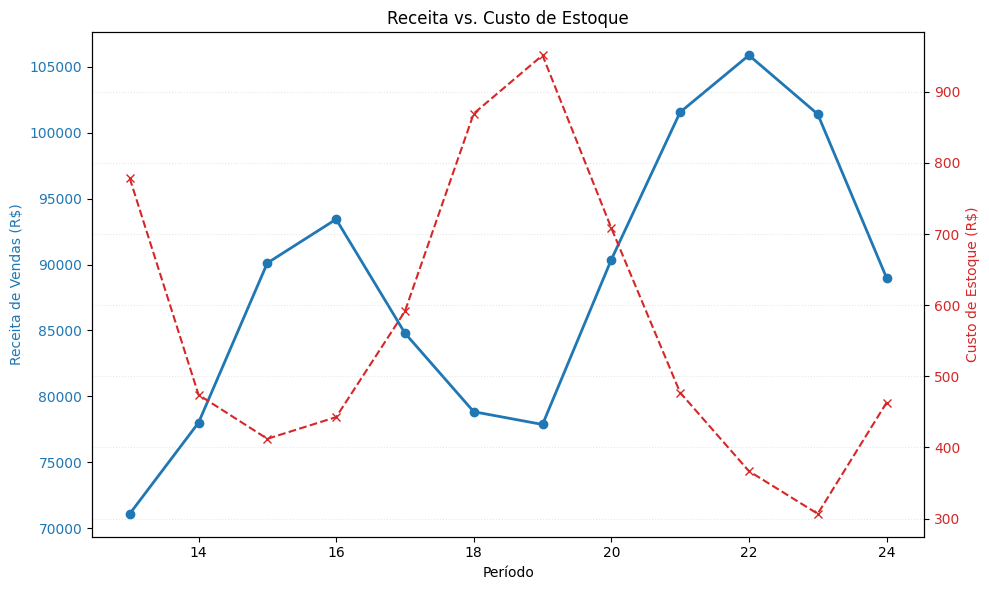

In [14]:
periodo = list(range(13, 25))

# Capacity Data
acab_disp = [70, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140]
acab_nec = [70, 71, 101, 98, 98, 86, 81, 87, 106, 105, 106, 98]

tec_disp = [1260, 1260, 1680, 1680, 1680, 1680, 1680, 1680, 1680, 1680, 1680, 1680]
tec_nec = [1090, 1209, 1583, 1542, 1525, 1361, 1271, 1378, 1680, 1680, 1680, 1510]

tint_disp = [14000, 14000, 20533, 19600, 19600, 19600, 19600, 19600, 19600, 19600, 19600, 19600]
tint_nec = [12740, 14000, 18265, 17745, 17550, 15600, 14690, 15730, 19175, 19073, 19080, 17615]

# Financial and Inventory Data
rec_vendas = [71091, 78003, 90117, 93438, 84797, 78835, 77867.5, 90373.5, 101556.5, 105877.5, 101412, 89000.5]
custo_estoques = [778.4, 474.1, 412.2, 442.7, 591.4, 869.4, 951.3, 708.4, 477.2, 366.8, 306.8, 462.9]

# 1. Occupancy Percentage Calculation
occ_acab = [(n/d)*100 for n, d in zip(acab_nec, acab_disp)]
occ_tec = [(n/d)*100 for n, d in zip(tec_nec, tec_disp)]
occ_tint = [(n/d)*100 for n, d in zip(tint_nec, tint_disp)]

# Plot 1: Occupancy (%)
plt.figure(figsize=(10, 6))
plt.plot(periodo, occ_acab, label='Acabamento', marker='o', color='green')
plt.plot(periodo, occ_tec, label='Tecelagem (Gargalo)', marker='s', color='red')
plt.plot(periodo, occ_tint, label='Tinturaria', marker='^', color='blue')
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5)
plt.title('Ocupação Percentual dos Processos (%)')
plt.xlabel('Período')
plt.ylabel('Utilização (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('ocupacao_percentual.png')

# Plot 2: Revenue vs Inventory Cost (Lean Validation)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Período')
ax1.set_ylabel('Receita de Vendas (R$)', color=color)
ax1.plot(periodo, rec_vendas, color=color, marker='o', linewidth=2, label='Receita')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Custo de Estoque (R$)', color=color)
ax2.plot(periodo, custo_estoques, color=color, marker='x', linestyle='--', label='Custo Estoque')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Receita vs. Custo de Estoque')
fig.tight_layout()
plt.grid(True, linestyle=':', alpha=0.3)
plt.savefig('lean_vendas_estoque.png')

print("Processamento concluído.")

### Evolução financeira e Custos

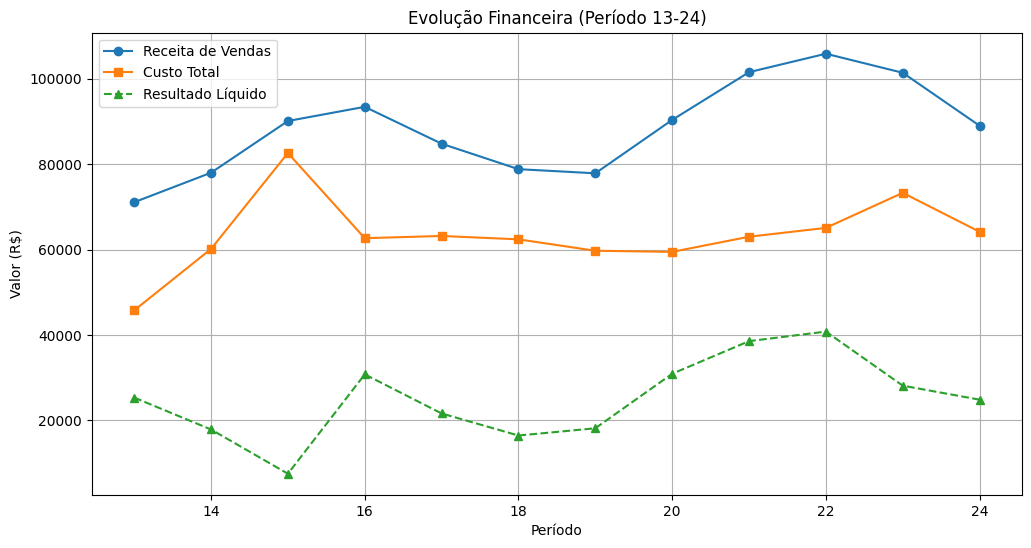

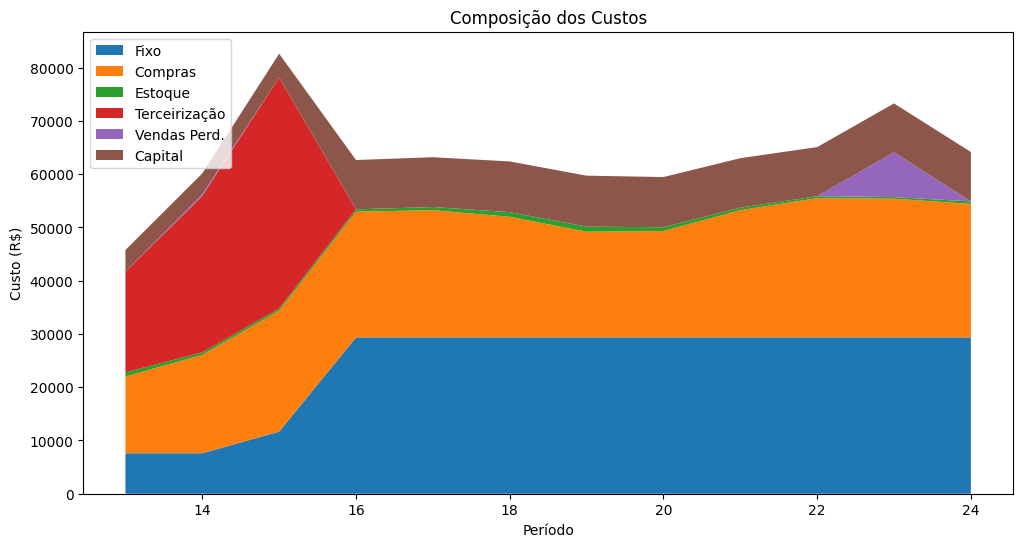

In [11]:
data = {
    'Periodo': [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'ROP_Acum': [25333.12, 43189.02, 50683.85, 81456.05, 103065.25, 119505.27, 137649.65, 168559.17, 207110.69, 247900.79, 276021.41, 300859.25],
    'ROP': [25333.12, 17855.90, 7494.83, 30772.20, 21609.20, 16440.02, 18144.38, 30909.52, 38551.52, 40790.10, 28120.62, 24837.84],
    'Rec_Vendas': [71091.0, 78003.0, 90117.0, 93438.0, 84797.0, 78835.0, 77867.5, 90373.5, 101556.5, 105877.5, 101412.0, 89000.5],
    'Custo_Total': [45757.9, 60147.1, 82622.2, 62665.8, 63187.8, 62395.0, 59723.1, 59464.0, 63005.0, 65087.4, 73291.4, 64162.7],
    'C_Fixos': [7600.0, 7600.0, 11666.6, 29360.0, 29360.0, 29360.0, 29360.0, 29360.0, 29360.0, 29360.0, 29360.0, 29360.0],
    'C_Compras': [14412.5, 18468.5, 22696.0, 23597.5, 23881.5, 22644.0, 19841.0, 19970.5, 23881.5, 26140.5, 26040.5, 25062.0],
    'C_Estoques': [778.4, 474.1, 412.2, 442.7, 591.4, 869.4, 951.3, 708.4, 477.2, 366.8, 306.8, 462.9],
    'C_Terc': [18900.0, 29400.0, 43400.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'C_Vendas_Perd': [0.0, 320.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8400.0, 0.0],
    'C_Capital': [4067.0, 3884.5, 4447.3, 9265.6, 9354.9, 9521.6, 9570.8, 9425.1, 9286.3, 9220.1, 9184.1, 9277.8]
}

df = pd.DataFrame(data)

# Calculations
df['Resultado_Liquido'] = df['Rec_Vendas'] - df['Custo_Total']
df['Margem_Percentual'] = (df['Resultado_Liquido'] / df['Rec_Vendas']) * 100
df['ROI_Periodo'] = (df['Resultado_Liquido'] / df['Custo_Total']) * 100

# Visualizations
plt.figure(figsize=(12, 6))
plt.plot(df['Periodo'], df['Rec_Vendas'], label='Receita de Vendas', marker='o')
plt.plot(df['Periodo'], df['Custo_Total'], label='Custo Total', marker='s')
plt.plot(df['Periodo'], df['Resultado_Liquido'], label='Resultado Líquido', marker='^', linestyle='--')
plt.title('Evolução Financeira (Período 13-24)')
plt.xlabel('Período')
plt.ylabel('Valor (R$)')
plt.legend()
plt.grid(True)
plt.savefig('financeiro_geral.png')

plt.figure(figsize=(12, 6))
plt.stackplot(df['Periodo'], 
              df['C_Fixos'], df['C_Compras'], df['C_Estoques'], 
              df['C_Terc'], df['C_Vendas_Perd'], df['C_Capital'],
              labels=['Fixo', 'Compras', 'Estoque', 'Terceirização', 'Vendas Perd.', 'Capital'])
plt.title('Composição dos Custos')
plt.xlabel('Período')
plt.ylabel('Custo (R$)')
plt.legend(loc='upper left')
plt.savefig('composicao_custos.png')

#print(df[['Periodo', 'Resultado_Liquido', 'Margem_Percentual', 'ROI_Periodo']].to_string())

### Mix de vendas produtos

Proporção do Mix de Vendas (%):
Colmeia    21.664140
Piquet     18.882619
Maxim      59.453241
dtype: float64

Crescimento Maxim (P13 para P22): 109.16%


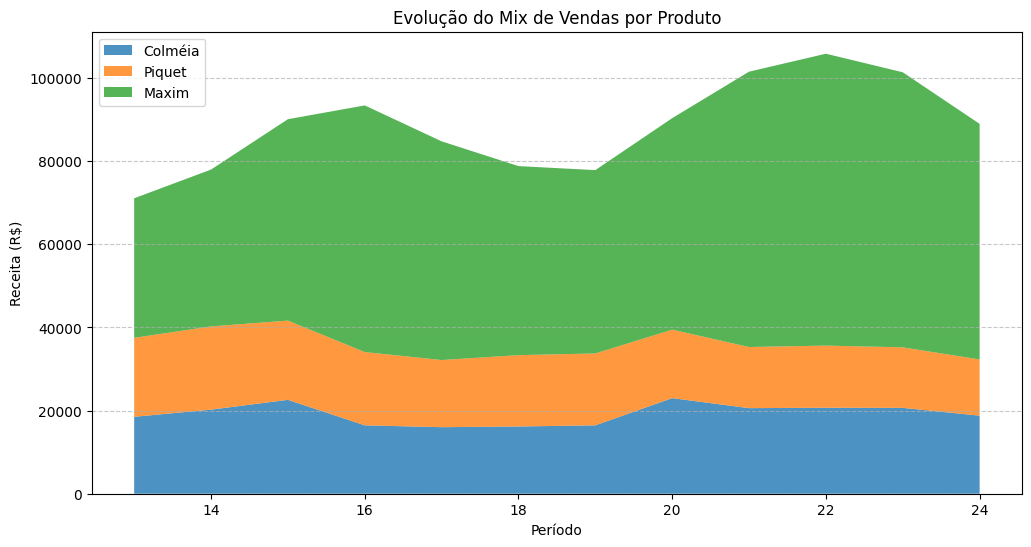

In [12]:
data_vendas = {
    'Periodo': [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'Colmeia': [18507.5, 20229.0, 22588.5, 16456.0, 16010.5, 16181.0, 16456.0, 23001.0, 20592.0, 20691.0, 20658.0, 18782.5],
    'Piquet': [19006.0, 20026.5, 19071.0, 17634.5, 16159.0, 17166.5, 17296.5, 16477.5, 14709.5, 14956.5, 14566.5, 13533.0],
    'Maxim': [33577.5, 37747.5, 48457.5, 59347.5, 52627.5, 45487.5, 44115.0, 50895.0, 66255.0, 70230.0, 66187.5, 56685.0]
}

df_vendas = pd.DataFrame(data_vendas)
df_vendas['Total'] = df_vendas['Colmeia'] + df_vendas['Piquet'] + df_vendas['Maxim']

# Proporção média do mix de vendas
total_periodo = df_vendas[['Colmeia', 'Piquet', 'Maxim']].sum()
proporcao = (total_periodo / total_periodo.sum()) * 100

print("Proporção do Mix de Vendas (%):")
print(proporcao)

# Plotando o mix de produtos ao longo do tempo
plt.figure(figsize=(12, 6))
plt.stackplot(df_vendas['Periodo'], df_vendas['Colmeia'], df_vendas['Piquet'], df_vendas['Maxim'], 
              labels=['Colméia', 'Piquet', 'Maxim'], alpha=0.8)
plt.title('Evolução do Mix de Vendas por Produto')
plt.xlabel('Período')
plt.ylabel('Receita (R$)')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('mix_vendas.png')

# Crescimento relativo (P13 vs P22 - Pico)
crescimento_maxim = ((df_vendas.loc[9, 'Maxim'] / df_vendas.loc[0, 'Maxim']) - 1) * 100
print(f"\nCrescimento Maxim (P13 para P22): {crescimento_maxim:.2f}%")

### ROI

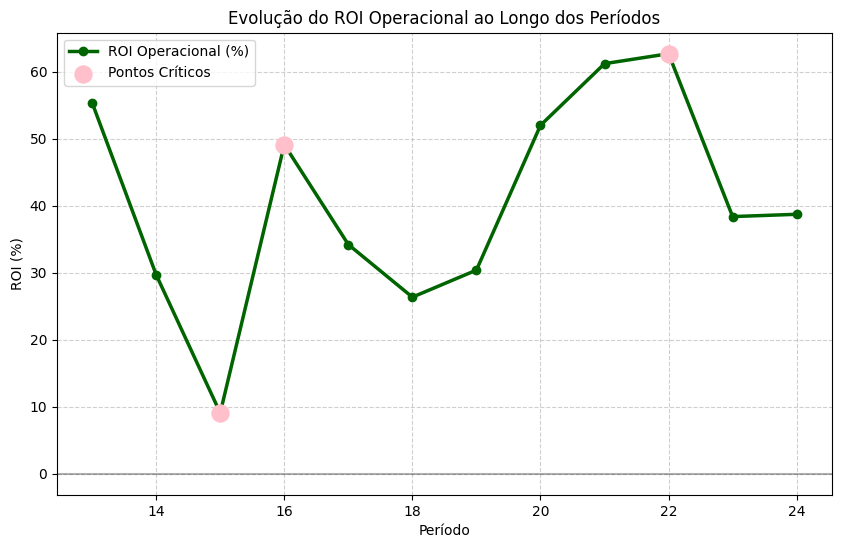

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados financeiros fornecidos anteriormente
data = {
    'Periodo': [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'Rec_Vendas': [71091.0, 78003.0, 90117.0, 93438.0, 84797.0, 78835.0, 77867.5, 90373.5, 101556.5, 105877.5, 101412.0, 89000.5],
    'Custo_Total': [45757.9, 60147.1, 82622.2, 62665.8, 63187.8, 62395.0, 59723.1, 59464.0, 63005.0, 65087.4, 73291.4, 64162.7]
}

df = pd.DataFrame(data)
df['Lucro_Liquido'] = df['Rec_Vendas'] - df['Custo_Total']
df['ROI_Percentual'] = (df['Lucro_Liquido'] / df['Custo_Total']) * 100

# Gráfico de ROI
plt.figure(figsize=(10, 6))
plt.plot(df['Periodo'], df['ROI_Percentual'], color='darkgreen', marker='o', linestyle='-', linewidth=2.5, label='ROI Operacional (%)')

# Pontos críticos
periodos_criticos = [15, 16, 22]
roi_criticos = df[df['Periodo'].isin(periodos_criticos)]['ROI_Percentual'].values
periodos_criticos_valores = df[df['Periodo'].isin(periodos_criticos)]['Periodo'].values

# Destacar pontos críticos em rosa
plt.scatter(periodos_criticos_valores, roi_criticos, color='pink', s=150, zorder=5, label='Pontos Críticos')

plt.title('Evolução do ROI Operacional ao Longo dos Períodos')
plt.xlabel('Período')
plt.ylabel('ROI (%)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('evolucao_roi.png')

#print(df[['Periodo', 'ROI_Percentual']].to_string())

### Capacidades

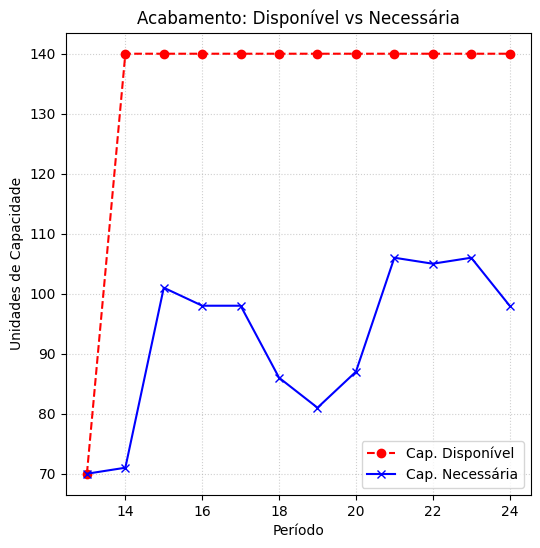

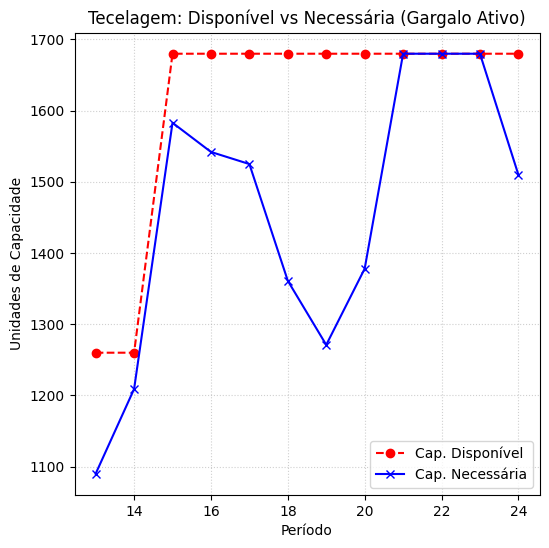

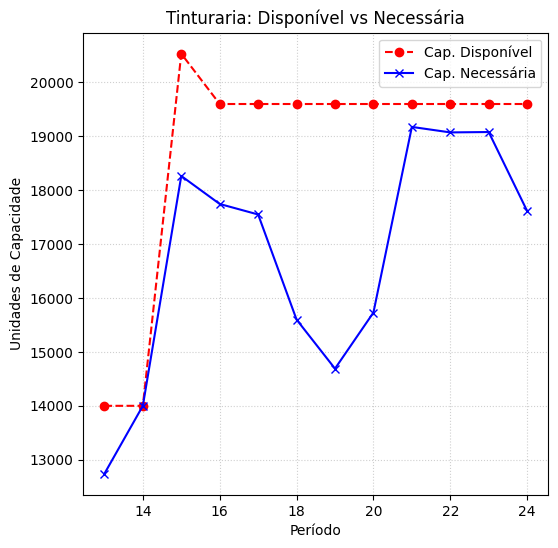

In [ ]:
# Dados de Acabamento
acabamento = {
    'Periodo': list(range(13, 25)),
    'Disp': [70, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140],
    'Nec': [70, 71, 101, 98, 98, 86, 81, 87, 106, 105, 106, 98]
}

# Dados de Tecelagem
tecelagem = {
    'Periodo': list(range(13, 25)),
    'Disp': [1260, 1260, 1680, 1680, 1680, 1680, 1680, 1680, 1680, 1680, 1680, 1680],
    'Nec': [1090, 1209, 1583, 1542, 1525, 1361, 1271, 1378, 1680, 1680, 1680, 1510]
}

# Dados de Tinturaria
tinturaria = {
    'Periodo': list(range(13, 25)),
    'Disp': [14000, 14000, 20533, 19600, 19600, 19600, 19600, 19600, 19600, 19600, 19600, 19600],
    'Nec': [12740, 14000, 18265, 17745, 17550, 15600, 14690, 15730, 19175, 19073, 19080, 17615]
}

# Plot Acabamento
plt.figure(figsize=(10, 6))
plt.plot(acabamento['Periodo'], acabamento['Disp'], 'r--', label='Cap. Disponível', marker='o')
plt.plot(acabamento['Periodo'], acabamento['Nec'], 'b-', label='Cap. Necessária', marker='x')
plt.title('Acabamento: Disponível vs Necessária')
plt.xlabel('Período')
plt.ylabel('Unidades de Capacidade')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('acabamento.png')
plt.show()

# Plot Tecelagem
plt.figure(figsize=(10, 6))
plt.plot(tecelagem['Periodo'], tecelagem['Disp'], 'r--', label='Cap. Disponível', marker='o')
plt.plot(tecelagem['Periodo'], tecelagem['Nec'], 'b-', label='Cap. Necessária', marker='x')
plt.title('Tecelagem: Disponível vs Necessária (Gargalo Ativo)')
plt.xlabel('Período')
plt.ylabel('Unidades de Capacidade')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('tecelagem.png')
plt.show()

# Plot Tinturaria
plt.figure(figsize=(10, 6))
plt.plot(tinturaria['Periodo'], tinturaria['Disp'], 'r--', label='Cap. Disponível', marker='o')
plt.plot(tinturaria['Periodo'], tinturaria['Nec'], 'b-', label='Cap. Necessária', marker='x')
plt.title('Tinturaria: Disponível vs Necessária')
plt.xlabel('Período')
plt.ylabel('Unidades de Capacidade')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('tinturaria.png')
plt.show()